Using this notebook to stack the data retrieved from OPERA, and reformat the time-series.

In [7]:
from datetime import datetime
from opera_utils import disp
import geopandas as gpd
import os
from pathlib import Path
import subprocess
from transboundary_opera import displacement_tools as dt
import matplotlib.pyplot as plt
import xarray as xr
from shapely.geometry import mapping
import ultraplot as uplt
from pyproj import CRS
import asf_search as asf
import re

# %matplotlib widget
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# aqufifer boundaries
gdf = gpd.read_file(Path(os.getcwd()).parent.parent / "raw_data/TBA_full.shp")

In [8]:
# Initialize a list to store frame IDs for each row
all_frame_ids = []

for entry, row in gdf.iterrows():
    
    results = asf.geo_search(
        intersectsWith=row.geometry.convex_hull.wkt,
        dataset=asf.DATASET.OPERA_S1,
        processingLevel=asf.PRODUCT_TYPE.DISP_S1,
        maxResults=50  # We only need a few results to identify the Frame IDs
    )
    
    # Set for the current row
    current_frame_ids = set()
    pattern = re.compile(r'_F(\d{5})_')

    for product in results:
        filename = product.properties['fileName']
        match = pattern.search(filename)
        if match:
            frame_id_str = match.group(1) 
            current_frame_ids.add(int(frame_id_str))
    
    # Add the sorted list of frame IDs to our collection
    all_frame_ids.append(sorted(list(current_frame_ids)))

# Assign the collected frame IDs to a new column in the GeoDataFrame
gdf['frame_ids'] = all_frame_ids

# TODO: attempt refined download for each of the frames that cover each aquifer. May need to clip the bbox of the aquifers and segment by the frame_ids

unique_frame_ids = sorted({fid for ids in gdf['frame_ids'] if isinstance(ids, (list, tuple, set)) for fid in ids})
len(unique_frame_ids)

["'type': 'GEOMETRY_SIMPLIFICATION': 'report': 'Shape Simplified: shape of 31 simplified to 21 with proximity threshold of 0.0004'", "'type': 'REVERSE': 'report': Reversed polygon winding order"]
["'type': 'GEOMETRY_SIMPLIFICATION': 'report': 'Shape Simplified: shape of 12 simplified to 11 with proximity threshold of 0.0004'", "'type': 'REVERSE': 'report': Reversed polygon winding order"]
["'type': 'GEOMETRY_SIMPLIFICATION': 'report': 'Shape Simplified: shape of 35 simplified to 24 with proximity threshold of 0.0004'", "'type': 'REVERSE': 'report': Reversed polygon winding order"]
["'type': 'GEOMETRY_SIMPLIFICATION': 'report': 'Shape Simplified: shape of 36 simplified to 25 with proximity threshold of 0.0004'", "'type': 'REVERSE': 'report': Reversed polygon winding order"]
["'type': 'GEOMETRY_SIMPLIFICATION': 'report': 'Shape Simplified: shape of 26 simplified to 21 with proximity threshold of 0.0004'", "'type': 'REVERSE': 'report': Reversed polygon winding order"]
["'type': 'GEOMETRY_

55

# Read in the OPERA netcdf files and stack into a dispProduct, also reforat the time-series to the initial date in the stack

In [ ]:
data_dir = Path('/home/clayc/Documents/US_Mex_InSAR') / "OPERA_data"

frame_disp_stacks = {}

for frame in os.listdir(data_dir):
    frame_dir = data_dir / str(frame)
    try:
        frame_disp_stacks[frame] = disp.DispProductStack.from_file_list(list(frame_dir.glob('*.nc')))
    except Exception as e:
        print(f"Could not create DispProductStack for frame {frame}: {e}")
        continue

for key, item in frame_disp_stacks.items():
    try:
        disp.reformat_stack(
            input_files=item.filenames,
            output_name=str(data_dir / f"{item.to_dataframe().frame_id.unique()[0]}_disp_stack.nc"),
            apply_solid_earth_corrections= True,
            apply_ionospheric_corrections= True,
            reference_method = 'high_coherence'    # 'border' or 'high_coherence'
        )
    except Exception as e:
        print(f"Could not reformat stack for frame {key}: {e}")
        continue

# Read in the newly reformatted stacks and throw some visuals
- Will try to make this interactive

In [9]:
data_dir = Path('/home/clayc/Documents/US_Mex_InSAR') / "OPERA_data"
disp_stacks = list(data_dir.glob('*_disp_stack.nc'))

In [ ]:
test_stack = disp_stacks[0]
ds = xr.open_dataset(test_stack)

wkt = ds.spatial_ref.crs_wkt
crs = CRS.from_wkt(wkt)

# try the simple route first, fallback to authority tuple
epsg = crs.to_epsg() or (int(crs.to_authority()[1]) if crs.to_authority() else None)

da_displacement_latlon = ds.displacement.rio.reproject("EPSG:4326")

In [17]:
test_boundaries = list(gdf[gdf['frame_ids'].apply(lambda x: float(test_stack.stem.replace('_disp_stack', '')) in x)].to_crs(epsg).geometry)

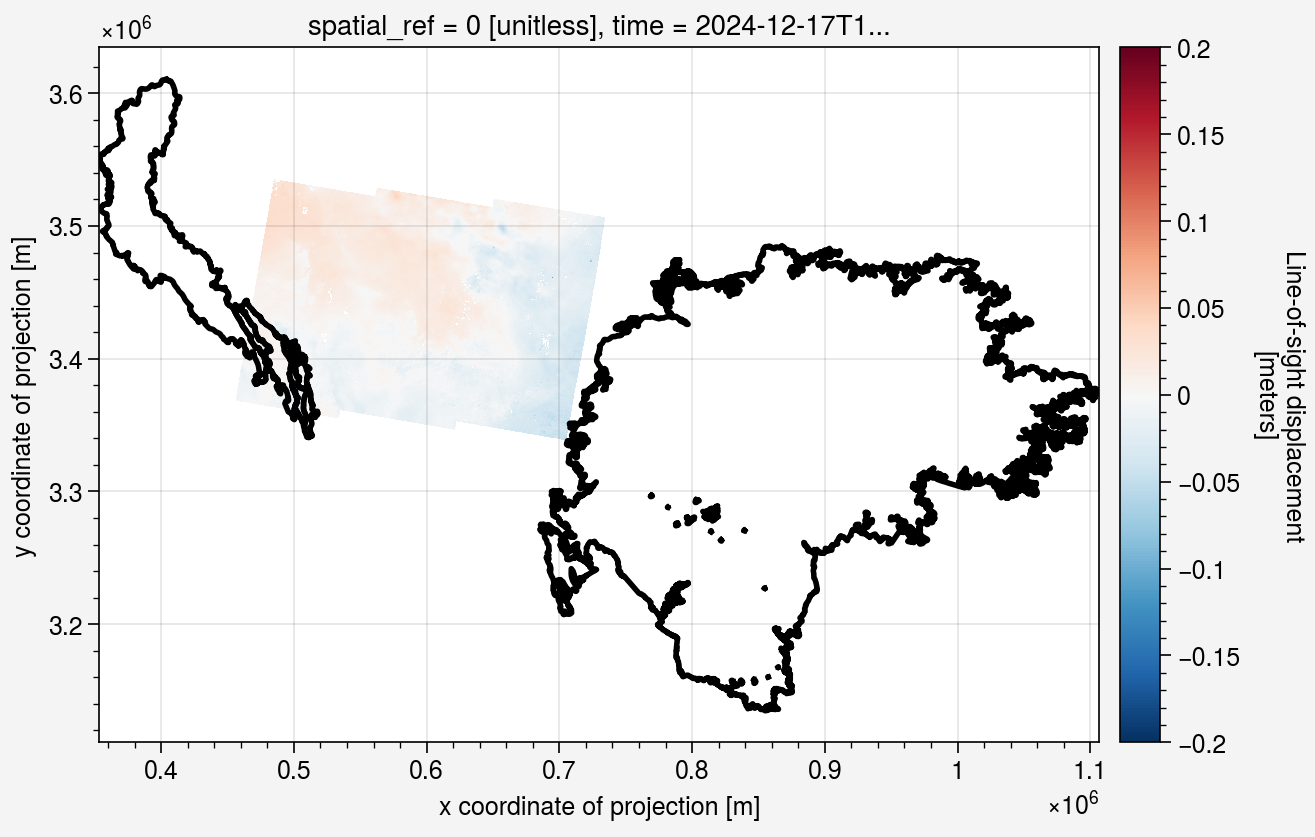

In [18]:
uplt.rc["image.cmap"] = "RdBu_r"
uplt.rc["image.interpolation"] = "nearest"

da_last = ds.displacement[-1]

strict_mask = (ds.temporal_coherence[-1] > 0.75) | (ds.phase_similarity[-1] > 0.6)

da_last_coarse = (
    # Apply the stricter mask
    da_last.where(strict_mask)
    # Coarsen 3 by 3 to make a 90 meter image
    .coarsen(x=3, y=3, boundary="trim")
    # Take the nan-aware median of each 3x3 window
    .median()
)

fig, ax = uplt.subplots(refwidth=5)
da_last_coarse.plot.imshow(ax=ax, vmax=0.2, vmin=-0.2, cmap="RdBu_r")
ax.set_aspect("equal")

# Add the aquifer boundary
# The key fix: use the coordinates from your DataArray, not the default axis coordinates
for boundary_proj in test_boundaries:
    if boundary_proj.geom_type == 'Polygon':
        x, y = boundary_proj.exterior.xy
        ax.plot(x, y, color='black', linewidth=2, label='Aquifer Boundary', transform=ax.transData)
    elif boundary_proj.geom_type == 'MultiPolygon':
        for geom in boundary_proj.geoms:
            x, y = geom.exterior.xy
            ax.plot(x, y, color='black', linewidth=2)
            # Add label only once for legend
            # ax.plot([], [], color='black', linewidth=2, label='Aquifer Boundary')

            # ax.legend()
# plt.tight_layout()

# Work on reformatting again into hdf5 for input into MintPy
- THIS NEEDS TO BE DONE. **We are specifically targeting the vertical displacement, OPERA datasets are in LOS**

In [19]:
ds

<xarray.Dataset> Size: 48GB
Dimensions:                         (time: 16, y: 6979, x: 9657)
Coordinates:
  * time                            (time) datetime64[ns] 128B 2024-06-08T12:...
  * y                               (y) float64 56kB 3.542e+06 ... 3.333e+06
  * x                               (x) float64 77kB 4.516e+05 ... 7.413e+05
    spatial_ref                     (time) int64 128B ...
Data variables: (12/14)
    reference_time                  (time) datetime64[ns] 128B ...
    water_mask                      (y, x) float32 270MB ...
    perpendicular_baseline          (time) float32 64B ...
    temporal_coherence              (time, y, x) float32 4GB ...
    phase_similarity                (time, y, x) float32 4GB ...
    persistent_scatterer_mask       (time, y, x) float32 4GB ...
    ...                              ...
    recommended_mask                (time, y, x) float32 4GB ...
    estimated_phase_quality         (time, y, x) float32 4GB ...
    shp_counts                      (time, y, x) float32 4GB ...
    average_temporal_coherence      (y, x) float32 270MB ...
    displacement                    (time, y, x) float64 9GB ...
    short_wavelength_displacement   (time, y, x) float32 4GB ...
Attributes:
    Conventions:         CF-1.8
    contact:             opera-sds-ops@jpl.nasa.gov
    institution:         NASA JPL
    mission_name:        OPERA
    reference_document:  JPL D-108765
    title:               OPERA_L3_DISP-S1 Product

Some target outputs:
1. COG, NetCDF, or H5 files containing the vertical displacement
2. COG, NetCDF, or H5 files containing the average vertical displacement velocity

- Would be pretty beneficial to have something set up to automatically retrieve the average vertical displacement velocities for a user input time period.
- Would also be beneficial to have an interactive map to visualize the data and select locations for the displacement and time-series parameters